
**Implementing Dog Breed Classification using Transfer Learning**

**Step 1: Import Necessary Libraries**

To implement this project, we will use the following Python libraries, each suited for specific tasks such as data handling, model development, and image processing:

* Pandas: For data manipulation and preprocessing.
* Numpy: For numerical computations and array manipulations.
* Matplotlib and Seaborn: For visualizing the dataset and model performance.
* Scikit-learn (Sklearn): For data preprocessing, splitting datasets, and model evaluation.
* OpenCV: For image processing tasks such as resizing, cropping, and converting images.
* TensorFlow and Keras: For building and training the deep learning model using transfer learning.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers
from functools import partial

import warnings
warnings.filterwarnings('ignore')
AUTO = tf.data.experimental.AUTOTUNE

**Step 2: Loading Dataset for Dog Breed Classification**

The dataset contains 10,000 images of 120 different dog breeds. The dataset includes:

* Training images: Contains labeled images of dog breeds.
* Test images: Unlabeled images used for testing the model.
* CSV file: Contains metadata about the images and their corresponding dog breed labels.

To start using the dataset, we will unzip the file to extract the contents.

In [ ]:
from zipfile import ZipFile
data_path = 'dog-breed-identification.zip'

with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('The data set has been extracted.')

The data set has been extracted.


**Step 3: Exploratory Data Analysis**

Now that we have the dataset, let's perform some basic Exploratory Data Analysis (EDA).

In [ ]:
df = pd.read_csv('labels.csv')
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


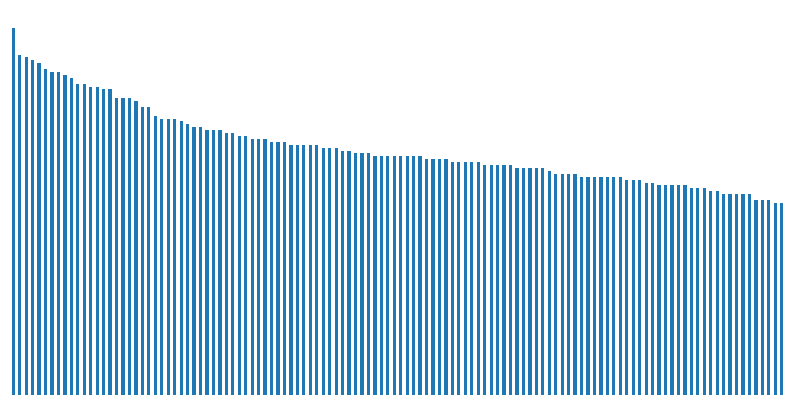

In [ ]:
plt.figure(figsize=(10, 5))
df['breed'].value_counts().plot.bar()
plt.axis('off')
plt.show()

In [ ]:
df['filepath'] = 'train/' + df['id'] + '.jpg'
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,pekinese,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


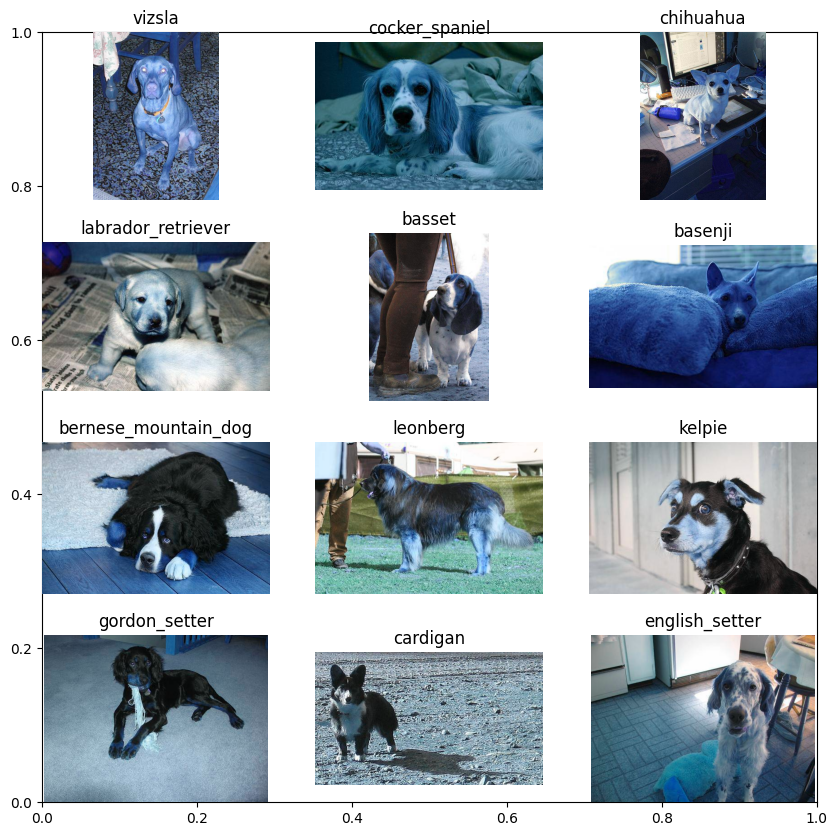

In [ ]:
plt.subplots(figsize=(10, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)

    # Selecting a random image
    # index from the dataframe.
    k = np.random.randint(0, len(df))
    img = cv2.imread(df.loc[k, 'filepath'])
    plt.imshow(img)
    plt.title(df.loc[k, 'breed'])
    plt.axis('off')
plt.show()

In [ ]:
le = LabelEncoder()
df['breed'] = le.fit_transform(df['breed'])
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,19,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,37,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,85,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,15,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,49,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


**Step 4: Data Preparation**

When working with large datasets in deep learning, memory limitations often prevent loading the entire dataset at once. To efficiently handle data loading and augmentation, tools like TensorFlow’s tf.data.Dataset and Albumentations are used to create optimized input pipelines and apply real-time image augmentations.

First, the dataset is split into training and validation sets, enabling model training on one subset and evaluation on another.

In [ ]:
features = df['filepath']
target = df['breed']

X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.15,
                                      random_state=10)

X_train.shape, X_val.shape

((8688,), (1534,))

**Step 5: Applying Image Augmentation**

Below are some of the augmentations which we would like to have in our training data.

In [ ]:
import albumentations as A

transforms_train = A.Compose([
    A.VerticalFlip(p=0.2),
    A.HorizontalFlip(p=0.7),
    A.CoarseDropout(p=0.5),
    A.RandomGamma(p=0.5),
    A.RandomBrightnessContrast(p=1)
])

Let's view an example of albumentation by applying it to some sample images.

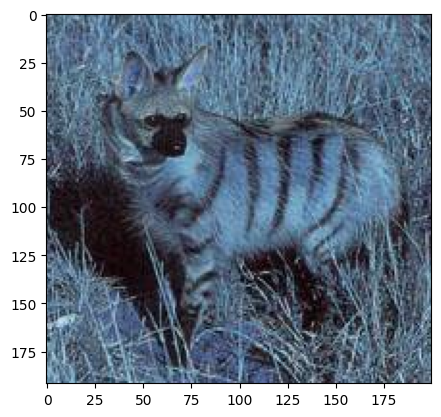

In [ ]:
img = cv2.imread('train/00792e341f3c6eb33663e415d0715370.jpg')
plt.imshow(img)
plt.show()

Next, we apply several augmentations, such as VerticalFlip, HorizontalFlip, CoarseDropout, and CLAHE, and visualize the results:

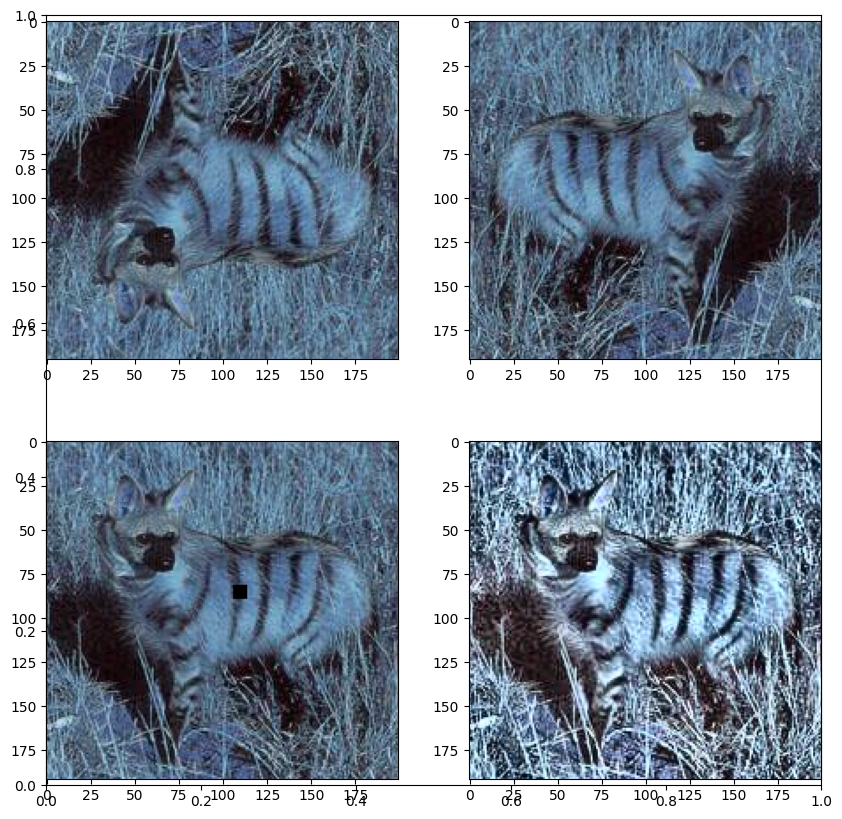

In [ ]:
augments = [A.VerticalFlip(p=1), A.HorizontalFlip(p=1),
            A.CoarseDropout(p=1), A.CLAHE(p=1)]

plt.subplots(figsize=(10, 10))
for i, aug in enumerate(augments):
    plt.subplot(2, 2, i+1)
    aug_img = aug(image=img)['image']
    plt.imshow(aug_img)
plt.show()

Different augmentations applied to the sample image, showing how the data transformation looks visually.

**Step 6: Building the Input Pipeline**

Now, let's define utility functions to handle image loading, augmentation, and normalization. We will create functions to read images from disk, resize them, normalize the pixel values, and apply augmentations.

Below we have implemented some utility functions which will be used while building the input pipeline.

    
* decode_image: This function will read the image from the path and resize them to be of the same size along with it will normalize as well. Finally, we will convert the labels into one_hot vectors as well.
* process_data: This is the function that will be used to introduce image augmentation to the image.

In [ ]:
def aug_fn(img):
    aug_data = transforms_train(image=img)
    aug_img = aug_data['image']

    return aug_img


@tf.function
def process_data(img, label):
    aug_img = tf.numpy_function(aug_fn,
                                [img],
                                Tout=tf.float32)

    return img, label


def decode_image(filepath, label=None):

    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, [128, 128])
    img = tf.cast(img, tf.float32) / 255.0

    if label == None:
        return img

    return img, tf.one_hot(indices=label,
                           depth=120,
                           dtype=tf.float32)

Now by using the above function we will be implementing our training data input pipeline and the validation data pipeline.

In [ ]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .map(partial(process_data), num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

We must observe here that we do not apply image data augmentation on validation or testing data.

In [ ]:
for img, label in train_ds.take(1):
  print(img.shape, label.shape)

(32, 128, 128, 3) (32, 120)


From here we can confirm that the images have been converted into (128, 128) shapes and batches of 64 images have been formed.

**Step 7: Model Building Using Transfer Learning**

1. Load Pre-trained InceptionV3 Model

We first load the InceptionV3 model from TensorFlow's Keras API with the weights pre-trained on ImageNet. The include_top=False argument excludes the fully connected layers at the top of the network, allowing us to customize the final layers for our task.

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

pre_trained_model = InceptionV3(
    input_shape=(128, 128, 3),
    weights='imagenet',
    include_top=False
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2. Inspect the Model's Depth

InceptionV3 is a deep network with many layers, which makes it effective in learning complex features from images. Let's check the number of layers in this pre-trained model.

In [ ]:
len(pre_trained_model.layers)

3. Freeze Pre-Trained Layers

Since the convolutional layers of the InceptionV3 model have already been trained on millions of images, we freeze these layers so that their weights are not updated during our fine-tuning process.

In [ ]:
for layer in pre_trained_model.layers:
  layer.trainable = False

last_layer = pre_trained_model.get_layer('mixed7')
# Access the output shape from the output tensor of the layer
print('last layer output shape: ', last_layer.output.shape)
last_output = last_layer.output

# This code is modified by Susobhan Akhuli

last layer output shape:  (None, 6, 6, 768)


4. Define the Custom Model Architecture

Using the Keras Functional API, we can build a custom classification head on top of the pre-trained model. This includes flattening the output, adding fully connected layers, BatchNormalization for stable training, Dropout for regularization, and finally, an output layer with softmax activation for multi-class classification.

In [ ]:
# Model Architecture
x = layers.Flatten()(last_output)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
output = layers.Dense(120, activation='softmax')(x)

model = keras.Model(pre_trained_model.input, output)

# Model Compilation
model.compile(
	optimizer='adam',
	loss=keras.losses.CategoricalCrossentropy(from_logits=True),
	metrics=[tf.keras.metrics.AUC()]
)

# This code is modified by Susobhan Akhuli

6. Implement Callbacks

Callbacks are used to monitor the model's performance during training. We use the following callbacks:

* EarlyStopping: Stops training if validation AUC doesn't improve for 3 consecutive epochs, preventing overfitting.
* ReduceLROnPlateau: Reduces the learning rate when the validation loss plateaus, helping the model converge better.
* Custom Callback: Stops training if the validation AUC exceeds 0.99.

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class myCallback(tf.keras.callbacks.Callback):
	def on_epoch_end(self, epoch, logs={}):
		if logs.get('val_auc') is not None and logs.get('val_auc') > 0.99:
			print('\n Validation accuracy has reached upto 90% so, stopping further training.')
			self.model.stop_training = True

es = EarlyStopping(patience=3,
                monitor='val_auc',
                restore_best_weights=True,
                mode='max')

lr = ReduceLROnPlateau(monitor='val_loss',
					patience=2,
					factor=0.5,
					verbose=1)

# This code is modified by Susobhan Akhuli


**Step 8: Train the Model**

We train the model using the fit() method with training and validation datasets, a maximum of 50 epochs, and the callbacks defined above.

In [ ]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5,
                    verbose=1,
                    callbacks=[es, lr, myCallback()])

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - auc: 0.7156 - loss: 4.3725 - val_auc: 0.9340 - val_loss: 2.6013 - learning_rate: 0.0010
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - auc: 0.9617 - loss: 2.2034 - val_auc: 0.9411 - val_loss: 2.3879 - learning_rate: 0.0010
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - auc: 0.9920 - loss: 1.1884 - val_auc: 0.9237 - val_loss: 2.4817 - learning_rate: 0.0010
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.9989 - loss: 0.4825
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
272/272 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - auc: 0.9989 - loss: 0.4822 - val_auc: 0.9115 - val_loss: 2.5616 - learning_rate: 0.0010
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - auc: 1.0000 - loss: 0.1759 - val_auc: 0.9267 - val_loss: 2.3344 - learning_rate: 5.0000e-04


**Step 9: Evaluate the Model**

Once the model is trained, we evaluate its performance on the test dataset. We visualize the training history to observe the model's learning curve and make sure it has converged effectively.

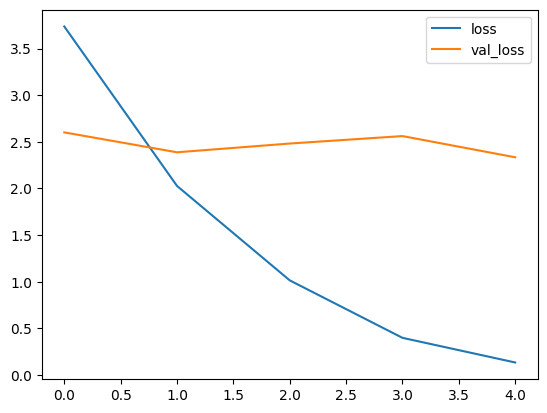

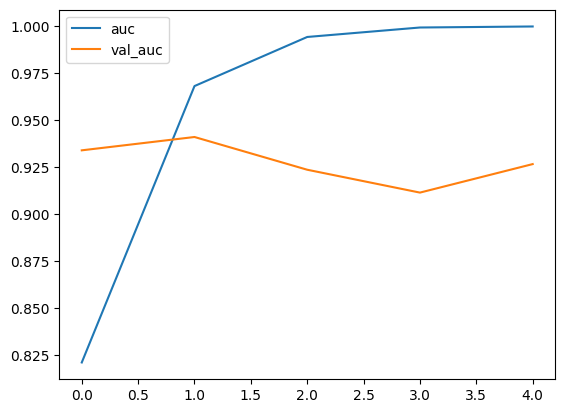

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['auc', 'val_auc']].plot()
plt.show()

The training and validation AUC curves are plotted, showing how the model's performance evolved over time. The test loss and test AUC are displayed, providing insight into how well the model generalizes to unseen data.